In [93]:
import os
import sys
import pandas as pd
import numpy as np
import math
import tensorflow as tf
import datetime
import matplotlib.pyplot as plt
verbose=1

In [94]:
## import data here
basesavepath = './.rawdata'
datasource= [f for f in os.listdir(basesavepath) if f.endswith(".pkl")]
df_temp = pd.read_pickle(f"{basesavepath}/{datasource[0]}")
df_temp.index = pd.to_datetime(df_temp['open_time'],format="%Y-%m-%d %H:%S:%S")

if verbose:
    print('dftemp head')
    print(df_temp.head(5))

#line below this builds a new df
# df = df_temp.iloc[:, [df_temp.columns.get_loc("open"),df_temp.columns.get_loc("volume")]]
df = df_temp.iloc[:, [df_temp.columns.get_loc("open")]]

if verbose:
    print('df head')
    print(df.head(5))

dftemp head
                              open_time     open     high      low    close  \
open_time                                                                     
2019-09-23 08:00:00 2019-09-23 08:00:00  9930.13  9930.13  9930.13  9930.13   
2019-09-23 13:00:00 2019-09-23 13:00:00  9930.13  9930.13  9930.13  9930.13   
2019-09-23 14:00:00 2019-09-23 14:00:00  9930.13  9930.13  9930.13  9930.13   
2019-09-23 15:00:00 2019-09-23 15:00:00  9930.13  9930.13  9930.13  9930.13   
2019-09-23 16:00:00 2019-09-23 16:00:00  9930.13  9930.13  9930.13  9930.13   

                        volume              close_time  quote_volume  count  \
open_time                                                                     
2019-09-23 08:00:00  1000000.0 2019-09-23 08:57:17.115       9.93013      1   
2019-09-23 13:00:00        0.0 2019-09-23 13:59:59.999       0.00000      0   
2019-09-23 14:00:00        0.0 2019-09-23 14:59:59.999       0.00000      0   
2019-09-23 15:00:00        0.0 2019-09-

In [95]:
# This preps data in correct format for RNN
# [[X][X][X][X]][Y]
# [[1][2][3][4]][5]
# [[2][3][4][5]][6]
windowsize=5
df_as_np = df.to_numpy()
X=[]
Y=[]
for i in range(len(df_as_np)-windowsize):
    row = [a for a in df_as_np[i:i+windowsize]]
    X.append(row)
    label = df_as_np[i+windowsize,0]
    Y.append(label)

prepX=np.array(X)
prepY=np.array(Y)

In [96]:
# split data into train, val, test sets
X_train, Y_train  = prepX[:45000], prepY[:45000]
X_val, Y_val  = prepX[45000:52000], prepY[45000:52000]
X_test, Y_test = prepX[52000:], prepY[52000:]

if verbose:
    print(X_train.shape, Y_train.shape) 
    print(X_val.shape, Y_val.shape) 
    print(X_test.shape, Y_test.shape) 
    print(X_train[1])

(45000, 5, 1) (45000,)
(7000, 5, 1) (7000,)
(6670, 5, 1) (6670,)
[[9930.13]
 [9930.13]
 [9930.13]
 [9930.13]
 [9930.13]]


In [97]:
# import things for model here
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

In [98]:
#Normalize data here
norm_layer = tf.keras.layers.Normalization(axis=-1)
norm_layer.adapt(X_train)

if verbose:
    print(norm_layer(X_train))

tf.Tensor(
[[[-1.2089912]
  [-1.2089912]
  [-1.2089912]
  [-1.2089912]
  [-1.2089912]]

 [[-1.2089912]
  [-1.2089912]
  [-1.2089912]
  [-1.2089912]
  [-1.2089912]]

 [[-1.2089912]
  [-1.2089912]
  [-1.2089912]
  [-1.2089912]
  [-1.2089912]]

 ...

 [[ 2.8637176]
  [ 2.8375332]
  [ 2.797705 ]
  [ 2.7881858]
  [ 2.7803328]]

 [[ 2.8375332]
  [ 2.797705 ]
  [ 2.7881858]
  [ 2.7803328]
  [ 2.7618046]]

 [[ 2.797705 ]
  [ 2.7881858]
  [ 2.7803328]
  [ 2.7618046]
  [ 2.8072236]]], shape=(45000, 5, 1), dtype=float32)


In [99]:
# create and train model here
model1 = Sequential()
model1.add(InputLayer((X_train.shape[1],X_train.shape[2])))
model1.add(norm_layer)
model1.add(LSTM(256, return_sequences=True))
model1.add(Dropout(0.1))
model1.add(LSTM(128, return_sequences=True))
model1.add(Dropout(0.1))
model1.add(LSTM(64))
model1.add(Dropout(0.1))
model1.add(Dense(32,'relu'))
model1.add(Dropout(0.1))
model1.add(Dense(16,'relu'))
model1.add(Dense(8,'linear'))
model1.add(Dense(1))

model1.summary()

cp = ModelCheckpoint(filepath='./.data/LSTM-model3.keras', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(), metrics=[RootMeanSquaredError()])

if verbose:
    print(tf.config.list_physical_devices())    

history=model1.fit(X_train,Y_train,validation_data=(X_val,Y_val), epochs=100, callbacks=[cp], verbose=verbose)     


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_14                │ (None, 5, 1)           │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_30 (LSTM)                  │ (None, 5, 256)         │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 5, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513,476 (1.96 MB)

 Trainable params: 513,473 (1.96 MB)

 Non-trainable params: 3 (16.00 B)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 318573056.0000 - root_mean_squared_error: 17848.6152 - val_loss: 1083443712.0000 - val_root_mean_squared_error: 32915.7070
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - loss: 11412738.0000 - root_mean_squared_error: 3378.2744 - val_loss: 784779392.0000 - val_root_mean_squared_error: 28013.9141
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - loss: 10737748.0000 - root_mean_squared_error: 3276.8503 - val_loss: 682836160.0000 - val_root_mean_squared_error: 26131.1348
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - loss: 10369882.0000 - root_mean_squared_error: 3220.2302 - val_loss: 537462016.0000 - val_root_mean_squared_error: 23183.2266
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - loss: 9976705.0000 - root_mean_squared_error: 3158.5923 - val_loss: 525518272.0000 - val_root_mean_squared_error: 22924.1855
Epoch 

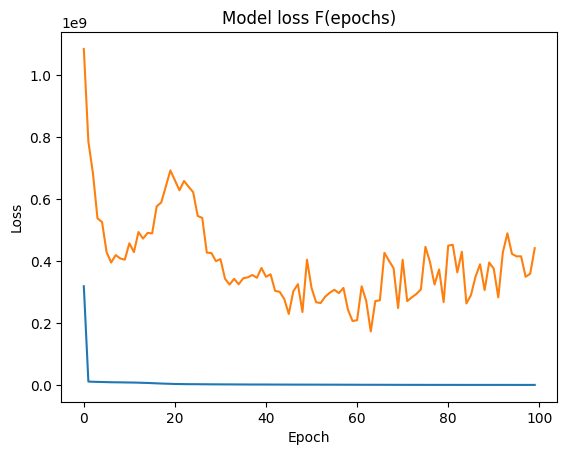

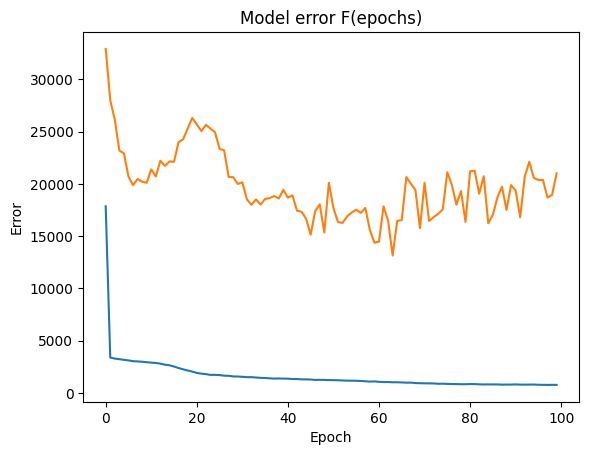

In [100]:
# this section evaluates and plots how well the model is doing
model1 = load_model('.data/LSTM-model3.keras') # load best model
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model loss F(epochs)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()


# this section evaluates and plots how well the model is doing
plt.plot(history.history['root_mean_squared_error'], label='rmse')
plt.plot(history.history['val_root_mean_squared_error'], label='rmse')
plt.title('Model error F(epochs)')
plt.ylabel('Error')
plt.xlabel('Epoch')
plt.show()

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step


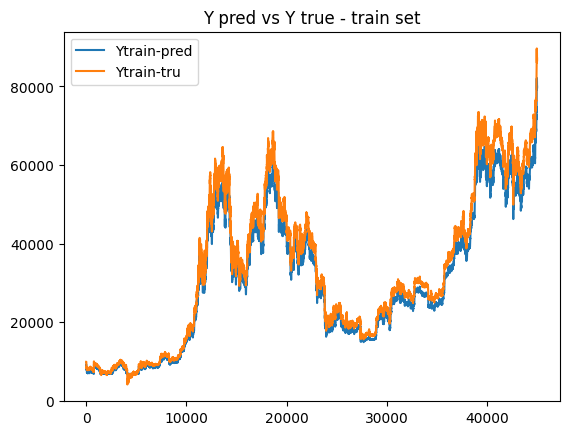

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


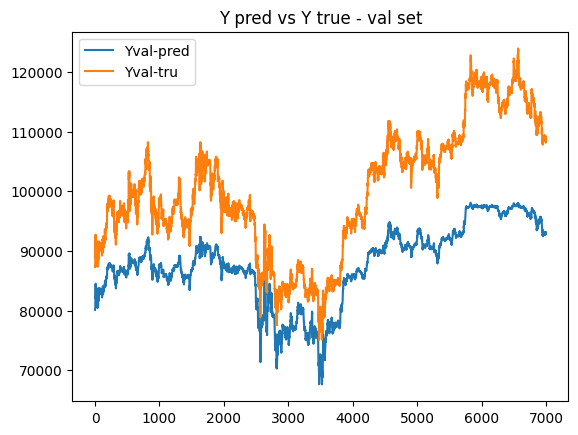

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


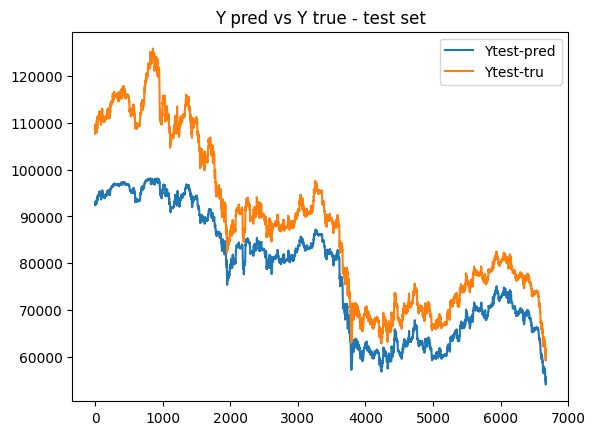

In [101]:
# how are the predictions??
y_train_pred = model1.predict(X_train)
y_train_pred = y_train_pred.squeeze()
y_train_true = Y_train.squeeze()

plt.plot(y_train_pred, label='Ytrain-pred')
plt.plot(y_train_true, label='Ytrain-tru')
plt.legend()
plt.title('Y pred vs Y true - train set')
plt.show()

# -----------------------------------------

y_val_pred = model1.predict(X_val)
y_val_pred = y_val_pred.squeeze()
y_val_true = Y_val.squeeze()

plt.plot(y_val_pred, label='Yval-pred')
plt.plot(y_val_true,label='Yval-tru')
plt.legend()
plt.title('Y pred vs Y true - val set')
plt.show()

# -----------------------------------------

y_test_pred = model1.predict(X_test)
y_test_pred = y_test_pred.squeeze()
y_test_true = Y_test.squeeze()

plt.plot(y_test_pred, label='Ytest-pred')
plt.plot(y_test_true, label='Ytest-tru')
plt.legend()
plt.title('Y pred vs Y true - test set')
plt.show()